Import all libraries

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

Define State

In [3]:
class BMIState(TypedDict):
    weight: float  # in kilograms
    height: float  # in meters
    bmi: float     # Body Mass Index

Logic of Node

In [4]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)

    return state

Define Graph

In [5]:
graph = StateGraph(BMIState)

Add Nodes to the graph

In [6]:
graph.add_node("Calculate BMI", calculate_bmi)# here the 1st field is the name of the node and the 2nd field is the function to be executed.

Add Edeges to the graph

In [7]:
graph.add_edge(START, "Calculate BMI")
graph.add_edge("Calculate BMI", END)

Graph Compilation

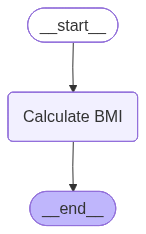

In [9]:
graph.compile()

In [10]:
workflow = graph.compile()

Graph Execution

In [13]:
initial_state = {"weight": 70.0, "height": 1.75}
final_state = workflow.invoke(initial_state)
print(f"Final State: {final_state}")

Final State: {'weight': 70.0, 'height': 1.75, 'bmi': 22.86}
